# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [18]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [19]:
# Load the prepared dataset from Phase 3
DATA_PATH = '../data/traffic_volume_prepared.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 48187 rows x 15 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,day_of_week,is_weekend,traffic_volume
0,3,288.28,0.0,0.0,40,1,24,2012-10-02 09:00:00,2012,10,2,9,1,0,5545
1,3,289.36,0.0,0.0,75,1,2,2012-10-02 10:00:00,2012,10,2,10,1,0,4516
2,3,289.58,0.0,0.0,90,1,19,2012-10-02 11:00:00,2012,10,2,11,1,0,4767
3,3,290.13,0.0,0.0,90,1,19,2012-10-02 12:00:00,2012,10,2,12,1,0,5026
4,3,291.14,0.0,0.0,75,1,2,2012-10-02 13:00:00,2012,10,2,13,1,0,4918


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [20]:
# TODO: Select and document your modelling techniques here.


modelling_techniques = {
    "problem_type": "Regression",
    "target_variable": "traffic_volume",
    "candidate_models": [
        {
            "name": "Linear Regression",
            "library": "sklearn.linear_model.LinearRegression",
            "justification": "Used as a simple baseline regression model to predict traffic volume and understand linear relationships between features and target.",
            "assumptions": "Assumes a linear relationship between features and target, independence of errors, and limited multicollinearity. It may not capture complex non-linear traffic patterns well."
        },
        {
            "name": "Ridge Regression",
            "library": "sklearn.linear_model.Ridge",
            "justification": "Useful when there may be correlated features. It improves Linear Regression by adding regularisation to reduce overfitting.",
            "assumptions": "Similar to Linear Regression, but handles multicollinearity better through L2 regularisation."
        },
        {
            "name": "Random Forest Regressor",
            "library": "sklearn.ensemble.RandomForestRegressor",
            "justification": "A strong ensemble model that can capture non-linear relationships and interactions between traffic-related features.",
            "assumptions": "Makes fewer assumptions about data distribution and can handle complex feature relationships well."
        },
        {
            "name": "Gradient Boosting Regressor",
            "library": "sklearn.ensemble.GradientBoostingRegressor",
            "justification": "A powerful boosting model that often performs well on structured/tabular datasets and can model more complex patterns in traffic volume.",
            "assumptions": "Does not assume linearity and works well with non-linear relationships, but may require tuning to avoid overfitting."
        }
    ]
}

modelling_techniques

{'problem_type': 'Regression',
 'target_variable': 'traffic_volume',
 'candidate_models': [{'name': 'Linear Regression',
   'library': 'sklearn.linear_model.LinearRegression',
   'justification': 'Used as a simple baseline regression model to predict traffic volume and understand linear relationships between features and target.',
   'assumptions': 'Assumes a linear relationship between features and target, independence of errors, and limited multicollinearity. It may not capture complex non-linear traffic patterns well.'},
  {'name': 'Ridge Regression',
   'library': 'sklearn.linear_model.Ridge',
   'justification': 'Useful when there may be correlated features. It improves Linear Regression by adding regularisation to reduce overfitting.',
   'assumptions': 'Similar to Linear Regression, but handles multicollinearity better through L2 regularisation.'},
  {'name': 'Random Forest Regressor',
   'library': 'sklearn.ensemble.RandomForestRegressor',
   'justification': 'A strong ensemble

In [21]:
# Import the specific model classes you plan to use
# Example imports (uncomment and modify as needed):

# Classification
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# Regression
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering
# from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


# Model classes were already imported in Cell 1.

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [22]:
# Ensure all features are numeric by converting datetime into separate components
df['date_time'] = pd.to_datetime(df['date_time'])

df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek

# Drop original datetime column
df = df.drop(columns=['date_time'])

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,year,month,day,hour,day_of_week,is_weekend,traffic_volume,dayofweek
0,3,288.28,0.0,0.0,40,1,24,2012,10,2,9,1,0,5545,1
1,3,289.36,0.0,0.0,75,1,2,2012,10,2,10,1,0,4516,1
2,3,289.58,0.0,0.0,90,1,19,2012,10,2,11,1,0,4767,1
3,3,290.13,0.0,0.0,90,1,19,2012,10,2,12,1,0,5026,1
4,3,291.14,0.0,0.0,75,1,2,2012,10,2,13,1,0,4918,1


In [23]:
# TODO: Define your test design and split the data.

RANDOM_SEED = 42
TEST_SIZE = 0.2

TARGET_COL = 'traffic_volume'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Feature matrix shape: (48187, 14)
Target vector shape: (48187,)
Training set: 38549 rows
Testing set: 9638 rows


In [24]:
# Document and justify the test design

test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "80/20 hold-out split with 5-fold cross-validation on the selected model",
    "stratified": False,
    "random_seed": RANDOM_SEED,
    "justification": "An 80/20 split provides enough data for training while keeping a separate test set for final evaluation. Cross-validation is used later to assess model stability and generalisability."
}

test_design

{'split_ratio': '80/20',
 'validation_strategy': '80/20 hold-out split with 5-fold cross-validation on the selected model',
 'stratified': False,
 'random_seed': 42,
 'justification': 'An 80/20 split provides enough data for training while keeping a separate test set for final evaluation. Cross-validation is used later to assess model stability and generalisability.'}

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [25]:
# TODO: Build and train your models.
# Store trained models in a dictionary for easy comparison.

# trained_models = {}

# --- Model 1 ---
# model_1 = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
# model_1.fit(X_train, y_train)
# trained_models['Logistic Regression'] = model_1

# --- Model 2 ---
# model_2 = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100)
# model_2.fit(X_train, y_train)
# trained_models['Random Forest'] = model_2

# --- Model 3 ---
# model_3 = GradientBoostingClassifier(random_state=RANDOM_SEED)
# model_3.fit(X_train, y_train)
# trained_models['Gradient Boosting'] = model_3

# print(f"Successfully trained {len(trained_models)} model(s).")


trained_models = {}

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
trained_models['Linear Regression'] = linear_model

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
trained_models['Ridge Regression'] = ridge_model

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED
)
rf_model.fit(X_train, y_train)
trained_models['Random Forest Regressor'] = rf_model

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED
)
gb_model.fit(X_train, y_train)
trained_models['Gradient Boosting Regressor'] = gb_model

print("Models trained successfully:")
for model_name in trained_models.keys():
    print("-", model_name)

Models trained successfully:
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor


In [26]:
# Hyperparameter tuning with GridSearchCV for Random Forest Regressor

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R² score:", round(grid_search.best_score_, 4))

best_rf_model = grid_search.best_estimator_
trained_models['Tuned Random Forest Regressor'] = best_rf_model

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation R² score: 0.9635


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [27]:
# Evaluate and compare all trained models
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R² Score', ascending=False).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R² Score
0,Random Forest Regressor,195.218133,348.394289,0.969640
1,Tuned Random Forest Regressor,195.218133,348.394289,0.969640
2,Gradient Boosting Regressor,346.057232,522.959338,0.931593
3,Ridge Regression,1586.953255,1799.243222,0.190261
4,Linear Regression,1586.951176,1799.244621,0.190260


Best Model: Random Forest Regressor
MAE:  195.2181
RMSE: 348.3943
R²:   0.9696


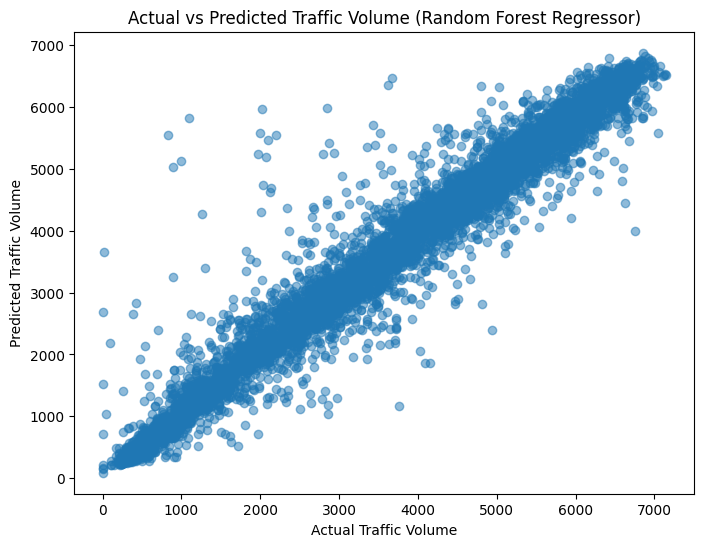

In [28]:
# Visualise results: Confusion Matrix for the best model (Classification)


best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_model_name}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_best):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title(f"Actual vs Predicted Traffic Volume ({best_model_name})")
plt.show()

In [29]:
# Cross-validation for the selected best model

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("Cross-Validation R² Scores:", np.round(cv_scores, 4))
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation R² Scores: [0.9466 0.9402 0.9229 0.9561 0.9394]
Mean R²: 0.9410
Standard Deviation: 0.0109
